# TF-IDF + Logistic Regression Baseline

This notebook implements the first supervised baseline for the Reddit-based happiness index project.
The goal is to train a traditional machine learning classifier on the VADER-labelled Reddit dataset
and evaluate its performance under a three-class sentiment setting: negative, neutral, and positive.

## 0. Environment Setup and Dependency Check

To ensure reproducibility and avoid runtime errors caused by missing dependencies, all required Python packages are verified and installed at the beginning of this notebook.

This notebook focuses on building a baseline sentiment classification model using TF-IDF features and Logistic Regression. Therefore, dependencies related to machine learning, data processing, and visualisation are included.

By performing this step, we ensure that the experimental environment is correctly configured before proceeding with data preprocessing, model training, and evaluation.

In [19]:
import importlib
import subprocess
import sys

def install_if_missing(package):
    try:
        importlib.import_module(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"⬇️ Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn"
]

for pkg in packages:
    install_if_missing(pkg)

✅ numpy already installed
✅ pandas already installed
⬇️ Installing scikit-learn...
✅ matplotlib already installed
✅ seaborn already installed


## 1. Load the VADER-labelled dataset

In this section, we load the CSV file produced in the previous notebook.  
This dataset contains Reddit comments, VADER sentiment labels, subreddit names, and timestamps.

In [20]:
import os
import pandas as pd

DATA_PATH = "../dataset/reddit_vader_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30000, 5)


,text,label,score,subreddit,created_utc
0,![gif](giphy|mFYTaY7Gth86xnE6N5),1,0.0000,MadeMeSmile,1640995203
1,Dayvon the boulder johnson.,1,0.0000,MadeMeSmile,1640995209
2,"As someone who has never been homeless, I can ...",0,-0.5423,MadeMeSmile,1640995213
3,Congrats!! That's awesome!!,2,0.8647,MadeMeSmile,1640995213
4,Congrats u f’ing legend!!!,2,0.6458,MadeMeSmile,1640995214


In [21]:
print(df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

print("\nSubreddit distribution:")
if "subreddit" in df.columns:
    print(df["subreddit"].value_counts())

['text', 'label', 'score', 'subreddit', 'created_utc']

Label distribution:
label
0     7300
1     7303
2    15397
Name: count, dtype: int64

Subreddit distribution:
subreddit
MadeMeSmile    10000
depression     10000
AskReddit      10000
Name: count, dtype: int64


## 2. Basic data quality checks

Before modelling, it is important to inspect missing values, duplicates, and invalid texts.
Although the data has already been filtered in the previous stage, a second check improves reproducibility
and makes the preprocessing pipeline clearer.

In [22]:
print("Missing values by column:")
print(df.isnull().sum())

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""]
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print("\nCleaned dataset shape:", df.shape)
df.head()

Missing values by column:
text           0
label          0
score          0
subreddit      0
created_utc    0
dtype: int64

Cleaned dataset shape: (29033, 5)


,text,label,score,subreddit,created_utc
0,![gif](giphy|mFYTaY7Gth86xnE6N5),1,0.0000,MadeMeSmile,1640995203
1,Dayvon the boulder johnson.,1,0.0000,MadeMeSmile,1640995209
2,"As someone who has never been homeless, I can ...",0,-0.5423,MadeMeSmile,1640995213
3,Congrats!! That's awesome!!,2,0.8647,MadeMeSmile,1640995213
4,Congrats u f’ing legend!!!,2,0.6458,MadeMeSmile,1640995214


## 3. Train/validation/test split

To keep the experimental design consistent with the thesis plan, the dataset is split into:
- 60% training set
- 10% validation set
- 30% test set

Stratified sampling is used so that the class distribution remains approximately consistent across splits.

In [23]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.75,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 17419
Validation size: 2903
Test size: 8711


In [24]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True).sort_index())

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train label distribution:
label
0    0.24990
1    0.23836
2    0.51174
Name: proportion, dtype: float64

Validation label distribution:
label
0    0.250086
1    0.238374
2    0.511540
Name: proportion, dtype: float64

Test label distribution:
label
0    0.249914
1    0.238319
2    0.511767
Name: proportion, dtype: float64


## 4. TF-IDF feature extraction

This section converts raw text into sparse numerical features using TF-IDF.
Unigrams and bigrams are included to capture both individual words and short phrase patterns,
which are often useful for sentiment classification.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (17419, 18410)
Validation TF-IDF shape: (2903, 18410)
Test TF-IDF shape: (8711, 18410)


## 5. Logistic Regression baseline

Logistic Regression is used here as a standard traditional NLP baseline.
It is lightweight, interpretable, and widely used in sentiment analysis studies.
Because the label distribution is somewhat imbalanced, class weighting is enabled.

In [26]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train_tfidf, y_train)
print("Model training completed.")

Model training completed.


## 6. Validation and model evaluation

The model is first checked on the validation set and then evaluated on the held-out test set.
Multiple metrics are reported, including accuracy, precision, recall, and F1-score.
These metrics are useful because overall accuracy alone may hide weaknesses in the neutral class.

In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_val_pred = clf.predict(X_val_tfidf)

print("Validation Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

Validation Accuracy: 0.7664

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.6671    0.7094    0.6876       726
           1     0.6864    0.8887    0.7746       692
           2     0.8866    0.7374    0.8051      1485

    accuracy                         0.7664      2903
   macro avg     0.7467    0.7785    0.7558      2903
weighted avg     0.7840    0.7664    0.7685      2903



In [28]:
y_test_pred = clf.predict(X_test_tfidf)

print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.775

Test Classification Report:
              precision    recall  f1-score   support

           0     0.6814    0.7152    0.6979      2177
           1     0.6922    0.8502    0.7631      2076
           2     0.8847    0.7692    0.8229      4458

    accuracy                         0.7750      8711
   macro avg     0.7527    0.7782    0.7613      8711
weighted avg     0.7880    0.7750    0.7774      8711



## 7. Confusion matrix

A confusion matrix helps show which classes are more easily confused by the model.
In this project, the neutral class is often expected to be the most difficult one,
because it lies between positive and negative emotional expressions.

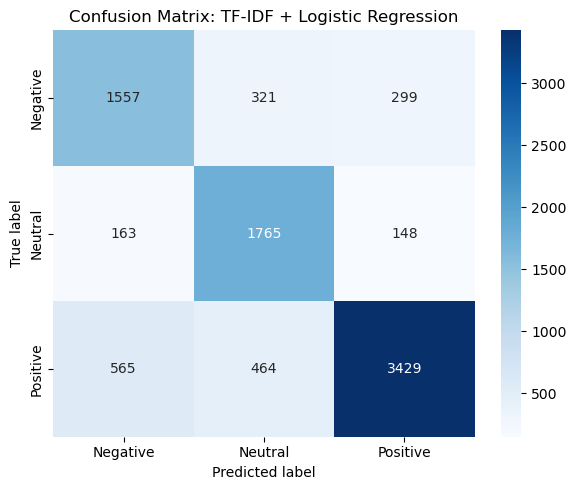

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',   # ⭐ 推荐配色（论文常用）
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")

plt.tight_layout()
plt.show()

## 8. Save split files and predictions

Saving the split files and model predictions makes later comparison easier.
These outputs can also be reused when writing the evaluation chapter or comparing with LSTM and BERT results.

In [30]:
output_dir = "../dataset/baseline_outputs"
os.makedirs(output_dir, exist_ok=True)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
test_df = pd.DataFrame({"text": X_test, "label": y_test, "pred_label": y_test_pred})

train_df.to_csv(os.path.join(output_dir, "train_60.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "val_10.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test_30_with_preds_tfidf_lr.csv"), index=False)

print("Saved split files and test predictions to:", output_dir)

Saved split files and test predictions to: ../dataset/baseline_outputs


## 9. Optional error analysis

This section extracts a few misclassified examples for qualitative analysis.
These examples are useful when discussing the limitations of TF-IDF features,
especially for sarcasm, context dependence, or emotionally mixed comments.

In [31]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": y_test_pred
})

error_df = error_df[error_df["true_label"] != error_df["pred_label"]].reset_index(drop=True)
print("Number of misclassified examples:", len(error_df))
error_df.head(20)

Number of misclassified examples: 1960


,text,true_label,pred_label
0,Wasps. I think they’re the only thing I’ve hea...,1,0
1,"Whilst I appreciate the sentiment mate, the fa...",2,0
2,"I have stopped ""texting first"" all together. I...",2,0
3,i wish i could open the gc and see “yall tryin...,2,0
4,My guess is clever editing.,2,1
5,My husband was kissed by a friend's coworker s...,0,2
6,"i'm no sommelier, just a wino. but if i was l...",2,0
7,"I can't speak for everyone, only myself. Scien...",0,2
8,Why should we be? I mean I'm not fearful but ...,2,0
9,Definitely not going to talk to any one. Can’t...,2,0
